# Token Dropping Example
-----

This example demonstrates how to use LMCache's SDK API to do KV cache 
modification, such as token dropping.

Requirements:
* This experiment needs a GPU. The GPU memory utilization should be adjusted 
  with the number of requests to show the benefit of token dropping in 
  increasing the batch size for decoding. 
  One RTX 6000 PRO is used for this example.
* This example uses shared memory, but when shared memory is not available, the 
  SDK will automatically use pickle.

## Setup vLLM and LMCache server
Follow below instructions (1-4), then proceed to below Python cell.

1. Start LMCache server first

To use shared memory, specify the `--shm-name` and `--no-l1-use-lazy`

```sh
lmcache server \
    --l1-size-gb 150 \
    --eviction-policy LRU \
    --chunk-size 256 \
    --port 6555 \
    --http-port 8080 \
    --shm-name lmcache_kvcache_sdk_e2e \
    --no-l1-use-lazy
```

2. Wait until LMCache server is ready

```sh
curl -sf http://localhost:8080/healthcheck && echo " LMCache ready"
```

3. Start vLLM once LMCache server is ready

We pass --no-enable-prefix-caching to disable vLLM's built-in prefix caching. 
This ensures the prefilled KV cache is always served from LMCache rather than 
vLLM, so the decoding throughput improvement can be attributed entirely to the 
tokens dropped through LMCache.

```sh
vllm serve Qwen/Qwen3-8B \
    --port 8000 \
    --served-model-name Qwen/Qwen3-8B \
    --no-enable-prefix-caching \
    --enforce-eager \
    --gpu-memory-utilization 0.5 \
    --kv-transfer-config '{"kv_connector":"LMCacheMPConnector","kv_role":"kv_both","kv_connector_extra_config":{"lmcache.mp.host":"tcp://localhost","lmcache.mp.port":6555,"lmcache.mp.mq_timeout":10}}' \
    --trust-remote-code \
    --return-tokens-as-token-ids
```

4. Wait until vLLM is ready

```sh
curl -sf http://localhost:8000/v1/models && echo " vLLM ready"
```

## Run E2E KV Edit Example

In [1]:
# SPDX-License-Identifier: Apache-2.0
"""End-to-end KV cache remapping driver for the SDK example."""

# Standard
from datasets import load_dataset
from matplotlib import pyplot as plt
import sys
from transformers import AutoTokenizer, AutoConfig

# Third Party
import torch

# First Party
from lmcache.logging import init_logger
import lmcache.sdk.kvcache as lmc_sdk
import lmcache.sdk.stream as lmc_stream
import lmcache.sdk.batch as lmc_batch
from lmcache.banner import print_banner_once
from utils import rerotate_k_cache, make_post_completion

print_banner_once(sys.stderr)
logger = init_logger(__name__)

/home/rani/LMCache/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[2026-07-02 19:18:41,149] LMCache INFO:  torch_dev=<module 'torch.cuda' from '/home/rani/LMCache/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py'>, torch_device_type=cuda (__init__.py:63:lmcache)
[2026-07-02 19:18:41,237] LMCache INFO: CudaPinMemoryBackend: using torch cudart (pin_memory.py:89:lmcache.v1.platform.cuda.pin_memory)
[2026-07-02 19:18:41,542] LMCache INFO: Skipping backend lmcache.v1.platform.musa.ops: predicate returned False (__init__.py:114:lmcache)
[2026-07-02 19:18:41,542] LMCache INFO: Skipping backend lmcache.xpu_ops: predicate returned False (__init__.py:114:lmcache)
[2026-07-02 19:18:41,544] LMCache INFO: Using backend: lmcache.c_ops (__init__.py:132:lmcache)
[2026-07-02 19:18:41,598] LMCache INFO: m

In [ ]:
model_name = "Qwen/Qwen3-8B"
vllm_url = "http://localhost:8000"
lmcache_url = "http://localhost:8080"
lmcache_mq_url = "tcp://localhost:6555"
chunk_size = 256
num_requests = 30
max_tokens = 5120
timeout = 60  # timeout for context retrieval (seconds)
trust_remote_code = True
drop_factor = 0.5

In [5]:
tokenizer = AutoTokenizer.from_pretrained(
    model_name, trust_remote_code=trust_remote_code
)
config = AutoConfig.from_pretrained(model_name, trust_remote_code=trust_remote_code)
head_size = getattr(
    config, "head_dim", config.hidden_size // config.num_attention_heads
)
work_device = torch.device("cpu")
post_completion = make_post_completion(vllm_url, model_name, timeout)
ctx = lmc_sdk.connect(
    url=lmcache_mq_url,
    http_url=lmcache_url,
    model_name=model_name,
    timeout=timeout,
)

[2026-07-02 19:18:57,068] LMCache INFO: Initialized LMCacheKVCacheContext with instance_id=3397043, model_name=Qwen/Qwen3-8B, chunk_size=256, shm_name=lmcache_l1_pool_lmcache_kvcache_sdk_e2e (kvcache.py:114:lmcache.sdk.kvcache)
[2026-07-02 19:18:57,080] LMCache INFO: Creating transfer context (device_type=cpu, mode=auto) (worker_transfer.py:551:lmcache.v1.multiprocess.transfer_context.worker_transfer)
[2026-07-02 19:18:57,080] LMCache INFO: Engine KV Format: EngineKVFormat.NL_X_NB_TWO_NH_BS_HS NL x [NB, 2, NH, BS, HS] (detection.py:44:lmcache.v1.gpu_connector.kv_format.detection)
[2026-07-02 19:18:57,082] LMCache INFO: Creating EngineDrivenContextShm (shm_name=lmcache_l1_pool_lmcache_kvcache_sdk_e2e, pool_size=161061273600) (base.py:235:lmcache.v1.multiprocess.transfer_context.base)
[2026-07-02 19:19:10,774] LMCache INFO: SHM pinned=True for shm_name=lmcache_l1_pool_lmcache_kvcache_sdk_e2e (shm.py:116:lmcache.v1.multiprocess.transfer_context.shm)
[2026-07-02 19:19:10,775] LMCache INFO:

## Constructing Prompt

In [14]:
prompts = []
ds = load_dataset("raniayu/token-dropping-demo", split="train")
for i, example in enumerate(ds):
    prompt = tokenizer.encode(ds[i]["prompt"], return_tensors="pt").squeeze(0).tolist()
    prompts.append(prompt)

print(f"Loaded {len(prompts)} prompts from the dataset.")
print(f"Total prompts length: {sum(len(p) for p in prompts)} tokens.")
print(f"Mean prompt length: {sum(len(p) for p in prompts) / len(prompts):.2f} tokens.")
print(f"Max prompt length: {max(len(p) for p in prompts)} tokens.")
print(f"Min prompt length: {min(len(p) for p in prompts)} tokens.")

Loaded 30 prompts from the dataset.
Total prompts length: 418566 tokens.
Mean prompt length: 13952.20 tokens.
Max prompt length: 16630 tokens.
Min prompt length: 10007 tokens.


## Baseline (without token dropping)

In [ ]:
batch = lmc_batch.LMCacheBatchedStream()
for i, prompt in enumerate(prompts):
    stream = lmc_stream.create_request(
        ctx=ctx,
        post_completion=post_completion,
        prompt_token_ids=prompt,
    )
    batch.add(stream)
results = batch.prefill(
    sampling_params={"max_tokens": 1, "temperature": 1.0, "ignore_eos": True}
)
results.emit()
results = batch.decode(
    sampling_params={"max_tokens": max_tokens, "temperature": 1.0, "ignore_eos": True}
)
results.emit()
before_drop_data = results.to_dict()

======================= Batched Stream Metrics (decode) ========================
-------------------------------- Configuration ---------------------------------
Number of Streams:                                                            30
----------------------------------- Results ------------------------------------
Total Duration (s):                                                       887.76
Total Output Tokens:                                                      153600
Output Throughput (tokens/s):                                             173.02
---------------------------- Time per Token (TPOT) -----------------------------
Mean TPOT (ms):                                                            66.98
P50 TPOT (ms):                                                             55.36
P90 TPOT (ms):                                                             56.42
P99 TPOT (ms):                                                             63.35
----------------------------

## Clear LMCache

In [16]:
!curl -X POST {lmcache_url}/clear-cache

{"status":"ok"}

## With Token Dropping

In [17]:
def drop_tokens_fn(
    kv_tensor: torch.Tensor, token_source: list[int]
) -> tuple[torch.Tensor, list[int]]:
    """Drop the middle half of the chunks, keeping the first and last intact.

    Args:
        kv_tensor: KV cache with shape [2, L, T, D]
        token_source: Token ids
    Returns:
        A tuple of the compacted KV tensor (on CPU) and the token ids.
    Raises:
        ValueError: If there are fewer than 3 chunks.
    """
    h = kv_tensor.shape[2]

    num_chunks = (h + chunk_size - 1) // chunk_size
    drop_count = num_chunks // 2
    if num_chunks < 3:
        raise ValueError("Not enough chunks to drop.")

    drop_start = (num_chunks - drop_count) // 2
    drop_start = max(1, min(drop_start, num_chunks - 1 - drop_count))

    lo = drop_start * chunk_size
    hi = (drop_start + drop_count) * chunk_size
    keep_idx = torch.cat([torch.arange(lo), torch.arange(hi, h)])
    kept_ids = token_source[:lo] + token_source[hi:]
    logger.info(f"compacting {drop_count}/{num_chunks} chunks")

    e_kv = rerotate_k_cache(
        kv_tensor[:, :, keep_idx, :].clone().to(work_device),
        old_positions=keep_idx.to(work_device),
        new_positions=torch.arange(
            keep_idx.numel(), device=work_device, dtype=torch.long
        ),
        model_config=config,
    )

    assert keep_idx[0].item() == 0 and keep_idx[-1].item() == h - 1
    return e_kv.cpu(), kept_ids

In [18]:
batch = lmc_batch.LMCacheBatchedStream()
for i, prompt in enumerate(prompts):
    stream = lmc_stream.create_request(
        ctx=ctx,
        post_completion=post_completion,
        prompt_token_ids=prompt,
    )
    batch.add(stream)

results = batch.prefill(
    sampling_params={"max_tokens": 1, "temperature": 1.0, "ignore_eos": True}
)
results.emit()

results = batch.modify(drop_tokens_fn)
results.emit()

results = batch.decode(
    sampling_params={"max_tokens": max_tokens, "temperature": 1.0, "ignore_eos": True}
)
results.emit()
after_drop_data = results.to_dict()

======================= Batched Stream Metrics (prefill) =======================
-------------------------------- Configuration ---------------------------------
Number of Streams:                                                            30
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        26.63
Total Input Tokens:                                                       418566
Input Throughput (tokens/s):                                            15717.52
-------------------------- Time to First Token (TTFT) --------------------------
Mean TTFT (ms):                                                         12999.61
P50 TTFT (ms):                                                          12858.49
P90 TTFT (ms):                                                          24862.84
P99 TTFT (ms):                                                          26575.42


[2026-07-02 19:54:18,009] LMCache INFO: compacting 19/39 chunks (3537216698.py:28:__main__)
[2026-07-02 19:54:18,082] LMCache INFO: compacting 21/42 chunks (3537216698.py:28:__main__)
[2026-07-02 19:54:18,091] LMCache INFO: compacting 19/39 chunks (3537216698.py:28:__main__)
[2026-07-02 19:54:18,116] LMCache INFO: compacting 21/42 chunks (3537216698.py:28:__main__)
[2026-07-02 19:54:18,188] LMCache INFO: compacting 21/43 chunks (3537216698.py:28:__main__)
[2026-07-02 19:54:18,198] LMCache INFO: compacting 22/44 chunks (3537216698.py:28:__main__)
[2026-07-02 19:54:18,383] LMCache INFO: compacting 23/47 chunks (3537216698.py:28:__main__)
[2026-07-02 19:54:18,388] LMCache INFO: compacting 21/42 chunks (3537216698.py:28:__main__)
[2026-07-02 19:54:18,399] LMCache INFO: compacting 24/49 chunks (3537216698.py:28:__main__)
[2026-07-02 19:54:18,877] LMCache INFO: compacting 25/50 chunks (3537216698.py:28:__main__)
[2026-07-02 19:54:18,893] LMCache INFO: compacting 32/64 chunks (3537216698.py:2

======================== Batched Stream Modify Metrics =========================
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        10.46
======================= Batched Stream Metrics (decode) ========================
-------------------------------- Configuration ---------------------------------
Number of Streams:                                                            30
----------------------------------- Results ------------------------------------
Total Duration (s):                                                       570.27
Total Output Tokens:                                                      153581
Output Throughput (tokens/s):                                             269.31
---------------------------- Time per Token (TPOT) -----------------------------
Mean TPOT (ms):                                                            79.08
P50 TPOT (ms):              

## Result Plot

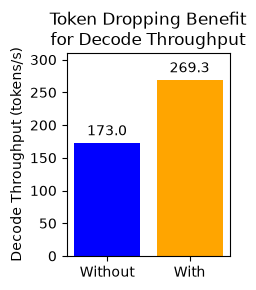

In [19]:
labels = ["Without", "With"]
data = [
    before_drop_data["metrics"]["results"]["output_tput"],
    after_drop_data["metrics"]["results"]["output_tput"],
]

fig, ax = plt.subplots(figsize=(2.5, 3))
bars = ax.bar(labels, data, color=["blue", "orange"])
ax.bar_label(bars, fmt="%.1f", padding=3)
ax.set_ylabel("Decode Throughput (tokens/s)")
ax.set_title("Token Dropping Benefit\nfor Decode Throughput")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

In [20]:
# Only close the context when done.
lmc_sdk.close(ctx)